In [1]:
import os
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 0. Configuration ────────────────────────────────────────────
base_dir = "../Data"
os.makedirs(base_dir, exist_ok=True)

ticker = "MBG.DE"
csv_price_file = os.path.join(base_dir, "MBG_DE_price_volume.csv")
csv_logret_file = os.path.join(base_dir, "MBG_DE_log_returns.csv")
csv_stdlogret_file = os.path.join(base_dir, "MBG_DE_std_log_returns.csv")
csv_vow_stdlogret_file = os.path.join(base_dir, "VOW_DE_std_log_returns.csv")

In [2]:
# ── 1. Download MBG.DE (DaimlerChrysler successor) ──────────────
def download_price_volume(ticker, csv_file):
    data = yf.download(ticker, start="1900-01-01", progress=False)

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.droplevel(1)

    data = data[["Close", "Volume"]].dropna()
    data.to_csv(csv_file)

    print(f"Saved {len(data)} rows -> {csv_file}")
    print(data.head())
    return data


data = download_price_volume(ticker, csv_price_file)

/var/folders/jp/bd398j317bgfry9k1hrttp6h0000gn/T/ipykernel_99517/3228962526.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="1900-01-01", progress=False)


Saved 7621 rows -> ../Data/MBG_DE_price_volume.csv
Price          Close   Volume
Date                         
1996-10-30  9.238611  1640521
1996-10-31  9.362068  1908031
1996-11-01  9.406000  2423211
1996-11-04  9.479242  1284644
1996-11-05  9.657111  2105206


In [3]:
# ── 2. Compute log returns and standardized log returns ─────────
def compute_returns(csv_price_file, csv_logret_file, csv_stdlogret_file):
    s = pd.read_csv(csv_price_file, parse_dates=["Date"]).set_index("Date")["Close"]
    s.index = pd.to_datetime(s.index, infer_datetime_format=True)

    lr = np.log(s / s.shift(1)).dropna()
    r_dcx = (lr - lr.mean()) / lr.std()

    lr.to_frame(name="log_return").to_csv(csv_logret_file)
    r_dcx.to_frame(name="Close").to_csv(csv_stdlogret_file)

    print(f"Saved {len(lr)} rows -> {os.path.basename(csv_logret_file)}")
    print(f"Saved {len(r_dcx)} rows -> {os.path.basename(csv_stdlogret_file)}")
    return lr, r_dcx


lr, r_dcx = compute_returns(csv_price_file, csv_logret_file, csv_stdlogret_file)


Saved 7620 rows -> MBG_DE_log_returns.csv
Saved 7620 rows -> MBG_DE_std_log_returns.csv


/var/folders/jp/bd398j317bgfry9k1hrttp6h0000gn/T/ipykernel_99517/3240859843.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  s.index = pd.to_datetime(s.index, infer_datetime_format=True)


In [4]:
# ── 3. Load standardized log returns for comparison ─────────────
def load_std_lr(path):
    s = pd.read_csv(path, parse_dates=["Date"], index_col="Date")["Close"]
    return s


r_dcx = load_std_lr(csv_stdlogret_file)
r_vow = load_std_lr(csv_vow_stdlogret_file)

In [5]:
# ── 4. Align series on common dates ──────────────────────────────
idx = r_dcx.index.intersection(r_vow.index)
x, y = r_dcx.loc[idx], r_vow.loc[idx]

start_str = idx[0].strftime("%Y%m%d")
end_str = idx[-1].strftime("%Y%m%d")
title = f"Log returns DCX & VW\n{start_str}-{end_str}"


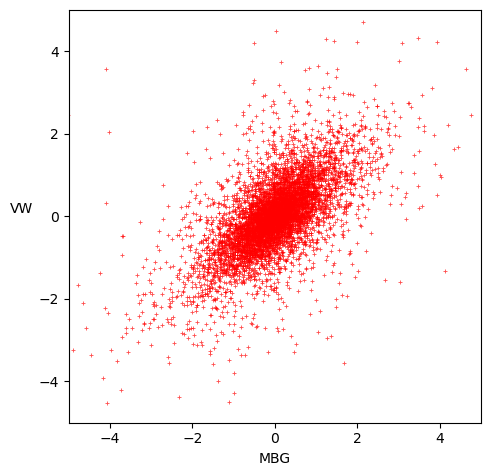

Plotted 7130 observations  (19980723 -> 20260608)


In [6]:
# ── 5. Plot scatter of aligned standardized returns ──────────────
def plot_scatter(x, y, start_str, end_str):
    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)

    ax.scatter(x, y, marker="+", color="red", s=10, linewidths=0.6, alpha=0.7)

    ax.set_xlabel("MBG", fontsize=10)
    ax.set_ylabel("VW", fontsize=10, rotation=0, labelpad=12)

    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_box_aspect(1)

    plt.tight_layout()
    plt.savefig("ScatterPlot_mbg_vow_full.png", dpi=150, bbox_inches="tight", transparent=True)
    plt.show()

    print(f"Plotted {len(x)} observations  ({start_str} -> {end_str})")


plot_scatter(x, y, start_str, end_str)